# 2. Coronagraphs: vortex and classical Lyot

Drop a coronagraph into the chain. The reference PSF used for Strehl normalization is always generated with the coronagraph bypassed (matches the legacy convention). First a `vortex` coronagraph, loading the fixture config that reproduces the original VortexCoronagraph(2) setup against a Keck aperture (HCIPy built-in); then a classical `lyot` train on a real VAMPIRES instrument mode, on both compute backends.

psf shape: (64, 64)  peak/min: 1.0 3.96912720616766e-06
pupil_opd RMS (nm): 0.0


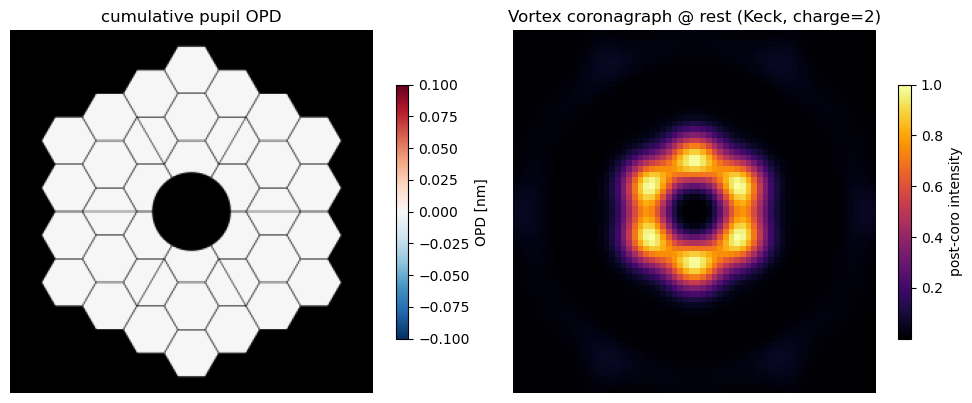

In [1]:
import hcipy
import numpy as np
import matplotlib.pyplot as plt
from telescope_sim import TelescopeSim

sim = TelescopeSim.from_yaml("fixtures/configs/07_coro_original.yaml")
out = sim.sample(meas_pupil_opd=True)
psf = out["images"]["psf"][..., 0]
print("psf shape:", psf.shape, " peak/min:", psf.max(), psf.min())
print('pupil_opd RMS (nm):', 1e9 * out['pupil_opd'].std())

# Pupil OPD (left) is ~0 at rest — Keck aperture transmits perfectly
# in-band. Even so, the coronagraph nulls the on-axis PSF (right).
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
opd_nm = hcipy.Field(
    1e9 * np.asarray(out['pupil_opd']), out['pupil_opd'].grid
)
plt.sca(axes[0])
im0 = hcipy.imshow_field(
    opd_nm, mask=sim.aperture.field, cmap='RdBu_r'
)
axes[0].set_title('cumulative pupil OPD')
axes[0].set_axis_off()
fig.colorbar(im0, ax=axes[0], shrink=0.7, label='OPD [nm]')
im1 = axes[1].imshow(psf, cmap='inferno')
axes[1].set_title('Vortex coronagraph @ rest (Keck, charge=2)')
axes[1].set_axis_off()
fig.colorbar(im1, ax=axes[1], shrink=0.7, label='post-coro intensity')
plt.tight_layout()
plt.show()


## Classical Lyot coronagraph

The `lyot` kind is a classical Lyot train: a hard-edged occulting spot in an intermediate focal plane plus an undersized/oversized Lyot stop back in the pupil. This config expresses a real instrument mode — VAMPIRES' CLC-3 spot (69 µm → 0.127 arcsec on sky) with the SCExAO pupil and its matching parametric Lyot stop. We clear the config's `per_sample_norm` so the coronagraphic image stays in the same physical units as the reference PSF and the suppression is directly visible.

core suppression: 7.41e-04
energy transmitted: 1.34%


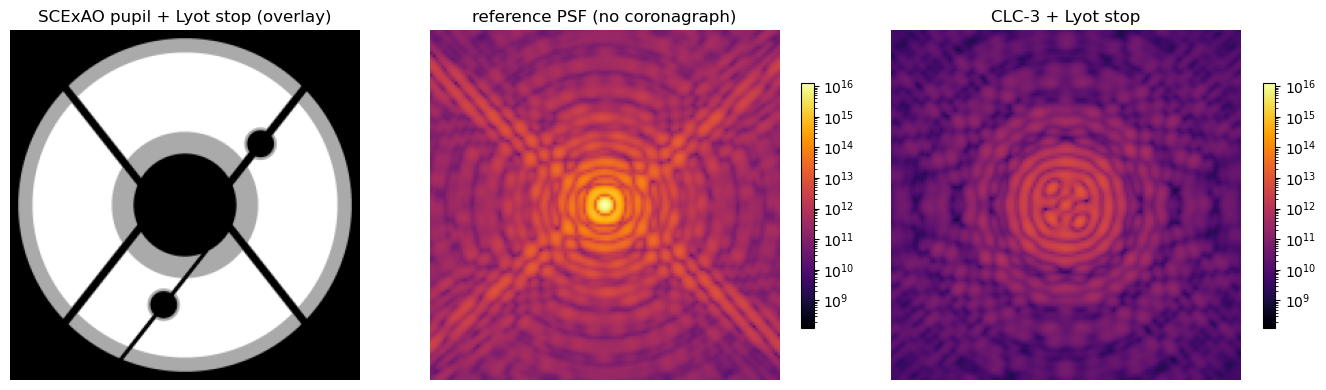

In [2]:
import yaml
from matplotlib.colors import LogNorm
from telescope_sim.config.loader import build
from telescope_sim.config.schema import SimConfig

with open("fixtures/configs/12_vampires_lyot.yaml") as f:
    raw = yaml.safe_load(f)
raw["outputs"]["psf"]["post_processing"] = []  # keep physical units
config = SimConfig.model_validate(raw)

sim = build(config)
coro = sim.sample()['images']['psf'][..., 0]
ref = sim.focal_planes['filter1'].reference_psf
peak = ref.max()
print(f'core suppression: {coro.max() / peak:.2e}')
print(f'energy transmitted: {coro.sum() / ref.sum():.2%}')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
stop_field = sim.coronagraph.lyot_field
plt.sca(axes[0])
hcipy.imshow_field(sim.aperture.field + 0.5 * stop_field, cmap='gray')
axes[0].set_title('SCExAO pupil + Lyot stop (overlay)')
axes[0].set_axis_off()
norm = LogNorm(vmin=peak * 1e-8, vmax=peak)
for ax, img, title in (
    (axes[1], ref, 'reference PSF (no coronagraph)'),
    (axes[2], coro, 'CLC-3 + Lyot stop'),
):
    im = ax.imshow(img, cmap='inferno', norm=norm)
    ax.set_title(title)
    ax.set_axis_off()
    fig.colorbar(im, ax=ax, shrink=0.7)
plt.tight_layout()
plt.show()


### Dual-backend: the Lyot train is in the JAX graph

Unlike the vortex kinds (currently HCIPy-only), `lyot` runs on both compute backends: the same config on `backend='jax'` folds the occulter/stop train into the propagation kernels, so `sample()`, `forward_fn`, and `sample_batch` all include it — batched, jitted, and differentiable. The two backends share the exact same geometry arrays and agree to float64 round-off.

In [3]:
import jax
import jax.numpy as jnp

sim_jax = build(config, backend='jax')
coro_jax = sim_jax.sample()['images']['psf'][..., 0]
print(f'max |hcipy - jax| (peak-normalized): '
      f'{abs(coro - coro_jax).max() / peak:.2e}')

# Differentiable through the coronagraph: gradient of the residual
# core flux with respect to the Zernike actuations.
fwd = sim_jax.forward_fn()
c = config.focal_planes['filter1'].focal_res // 2

def core_flux(acts):
    img = fwd(acts)['filter1']
    return img[c - 6 : c + 6, c - 6 : c + 6].sum()

grad = jax.grad(core_flux)({'zernike_dm': jnp.zeros(35)})
print('d(core flux)/d(zernike) shape:', grad['zernike_dm'].shape)
print('largest-sensitivity modes:', jnp.argsort(-abs(grad['zernike_dm']))[:5])


max |hcipy - jax| (peak-normalized): 3.63e-18


d(core flux)/d(zernike) shape: (35,)
largest-sensitivity modes: [32 31 14 28 16]
